Base directory: /Users/danayaptangco/local_code/Mulders/tess_demographics/gen_heatmaps/inj_rec/for_geryon/import_to_geryon/injected_flattened_lcs/TIC_396901084


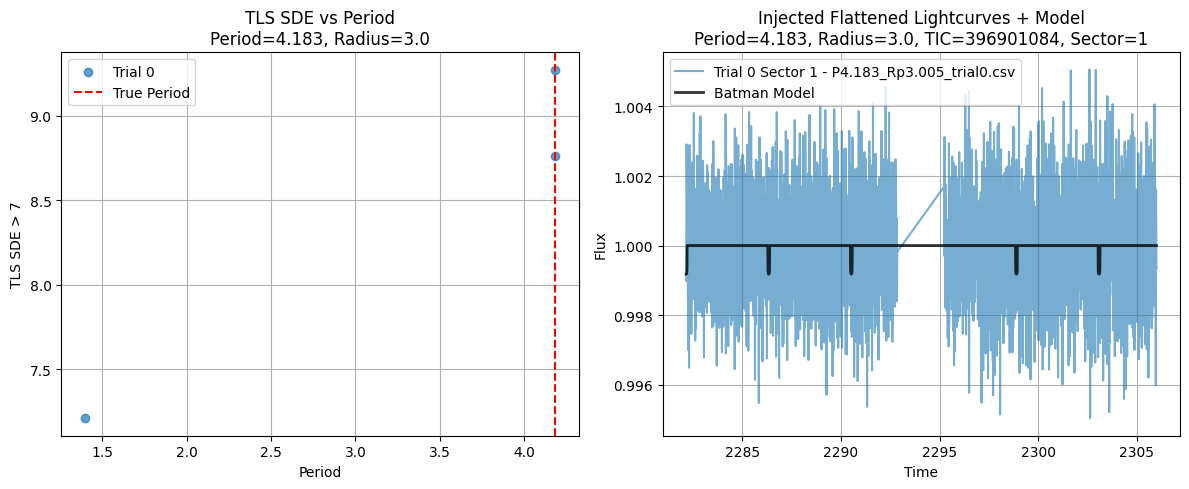

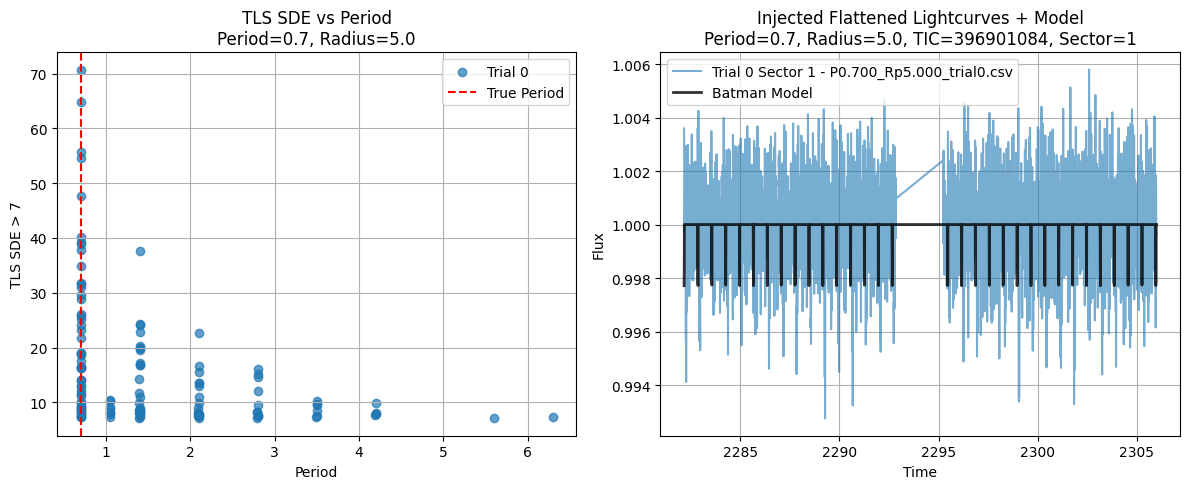

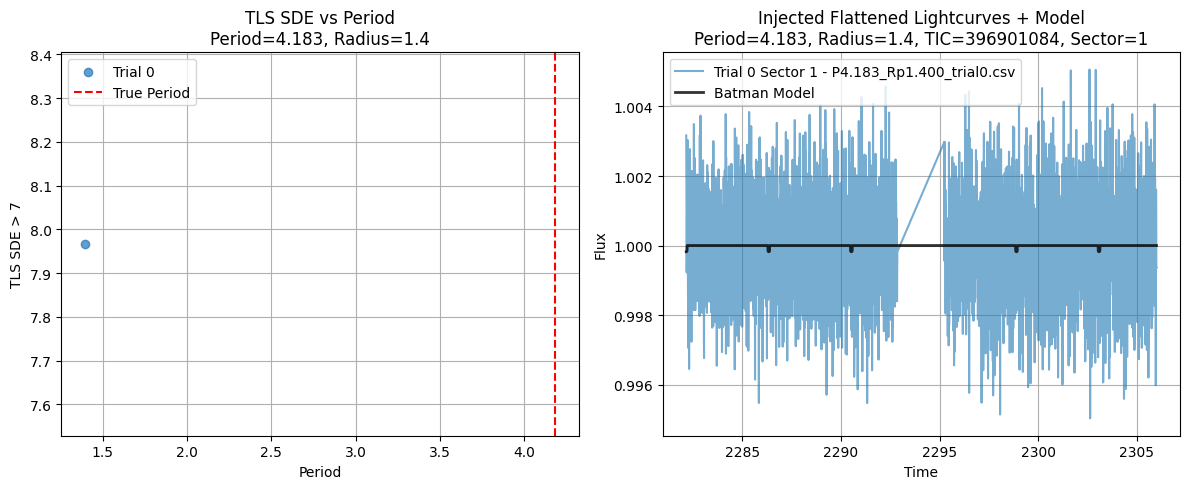

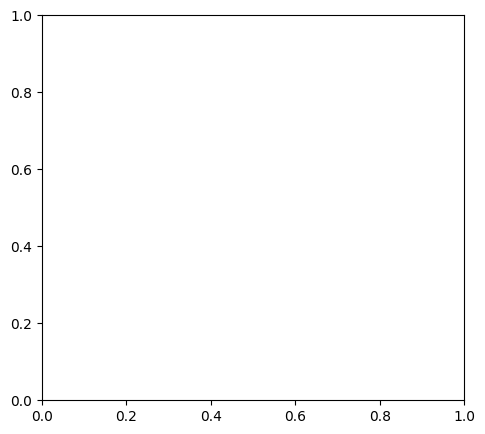

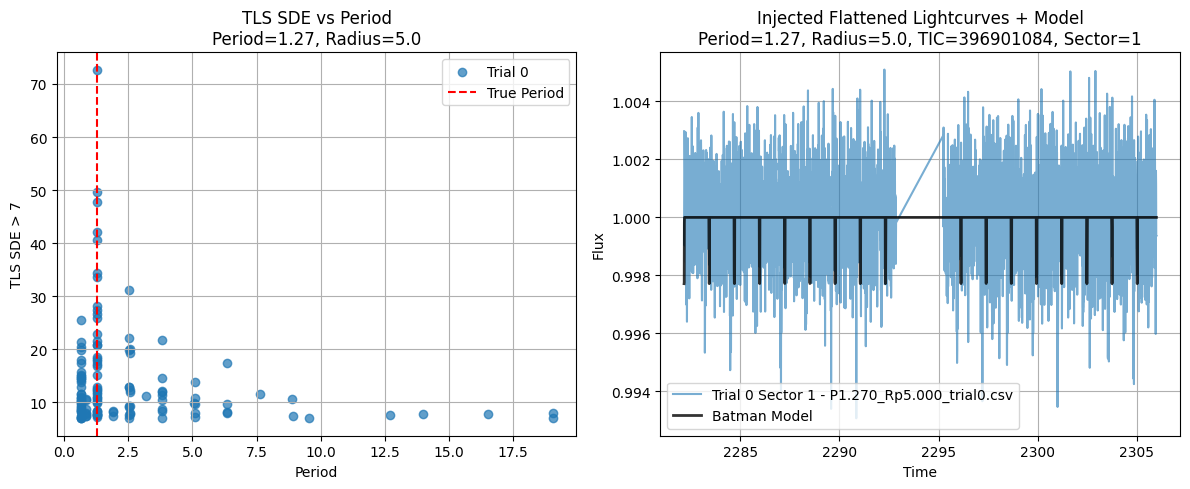

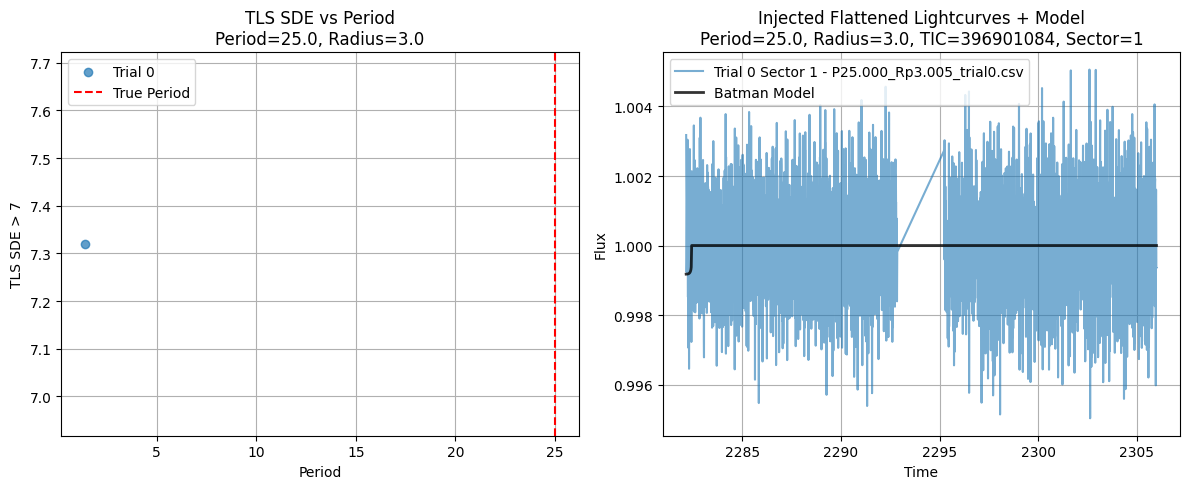

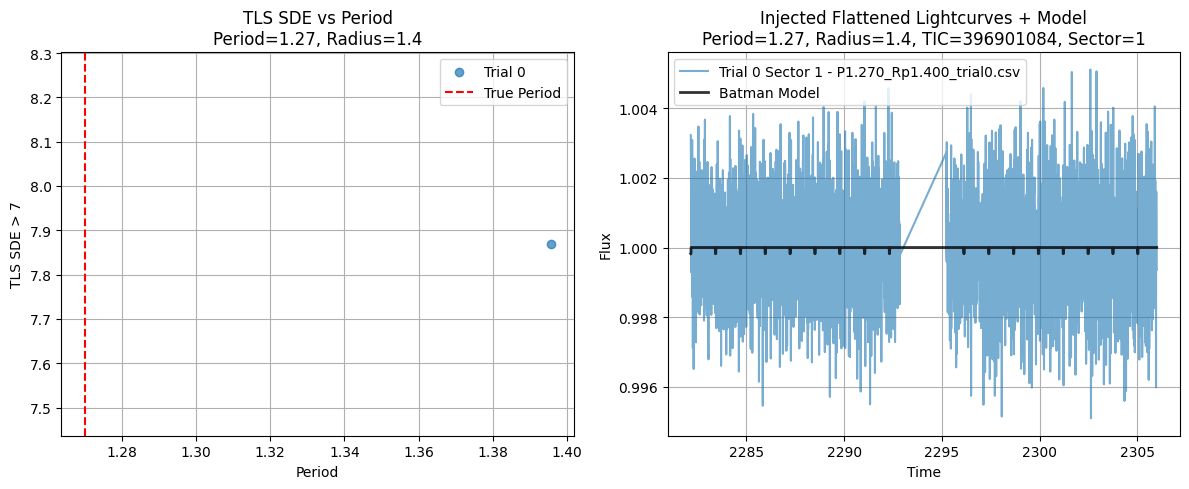

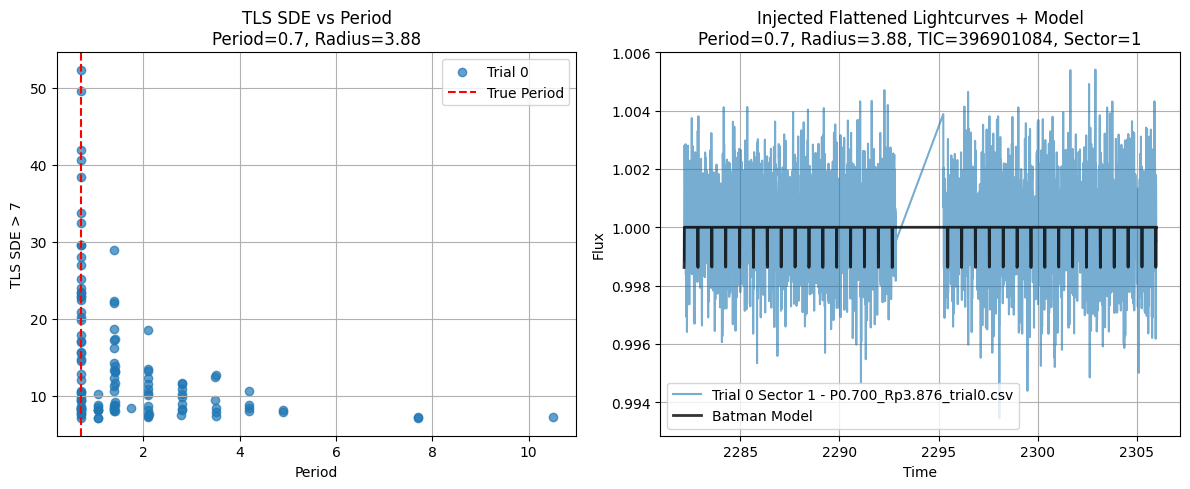

KeyboardInterrupt: 

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import math
import numpy as np
import batman

def truncate(val, decimals=1):
    factor = 10 ** decimals
    return math.floor(val * factor) / factor
def plot_tls_and_lc(
    df,
    tic,
    base_dir_root="/Users/danayaptangco/local_code/Mulders/tess_demographics/gen_heatmaps/inj_rec/for_geryon/import_to_geryon/injected_flattened_lcs",
    period=None,
    radius=None,
    sector_idx=0
):
    base_dir = os.path.join(base_dir_root, f"TIC_{tic}")
    print(f"Base directory: {base_dir}")

    tic_str = f'TIC {tic}'
    df_tic = df[df['TIC'] == tic_str]
    unique_pairs = df_tic[['True Period (Days)', 'True Radius (Earth Radii)']].drop_duplicates().values

    for (true_period, true_radius) in unique_pairs:

        row = df[(df['TIC'] == tic_str) &
                 (df['True Period (Days)'] == true_period) &
                 (df['True Radius (Earth Radii)'] == true_radius)]

        # Optional filtering if user requested specific period/radius
        if (period is not None and abs(true_period - period) > 1e-5) or \
           (radius is not None and abs(true_radius - radius) > 1e-5):
            continue

        # Stellar radius placeholder
        stellar_radius = 1.0
        if pd.isna(stellar_radius):
            print(f"Stellar radius missing for Period={true_period}, Radius={true_radius}, skipping batman model")
            continue

        # = row['Detected'].values[0]

        plt.figure(figsize=(12, 5))

        # --- Left subplot: TLS SDE vs Period ---
        plt.subplot(1, 2, 1)
        try:
            periods = [float(p) for p in row['TLS Periods array'].iloc[0].strip('[]').split()]
            sde = [float(s) for s in row['TLS SDE > 7 array'].iloc[0].strip('[]').split()]
        except Exception as e:
            print(f"Skipping due to parse error: {e}")
            continue
        if len(periods) != len(sde) or len(periods) == 0:
            continue

        plt.scatter(periods, sde, label="Trial 0", alpha=0.7)
        plt.axvline(true_period, color='red', linestyle='--', label='True Period')
        plt.xlabel('Period')
        plt.ylabel('TLS SDE > 7')
        plt.title(f'TLS SDE vs Period\nPeriod={true_period}, Radius={true_radius}')
        plt.legend()
        plt.grid(True)

        # --- Right subplot: Lightcurve + batman model ---
        plt.subplot(1, 2, 2)
        trial = 0
        period_pattern = f"P{truncate(true_period, 1):.1f}*"
        radius_pattern = f"Rp{truncate(true_radius, 1):.1f}*"
        pattern = os.path.join(base_dir, f"{period_pattern}_{radius_pattern}_trial{trial}.csv")
        matching_files = glob.glob(pattern)

        if not matching_files:
            print(f"No files found matching pattern: {pattern}")
            continue

        for filepath in matching_files:
            lc_df = pd.read_csv(filepath)
            time = lc_df['time'].values
            flux = lc_df['flux'].values

            # Select sector if needed
            if sector_idx is None:
                plt.plot(time, flux, alpha=0.6, label=f"Trial {trial} - {os.path.basename(filepath)}")
                time_to_model = time
            else:
                gap_indices = np.where(np.diff(time) > 10)[0]
                sector_boundaries = np.concatenate(([-1], gap_indices, [len(time) - 1]))
                if sector_idx >= len(sector_boundaries) - 1:
                    print(f"Sector {sector_idx} out of range for file {os.path.basename(filepath)}")
                    continue
                start_idx = sector_boundaries[sector_idx] + 1
                end_idx = sector_boundaries[sector_idx + 1] + 1
                sector_time = time[start_idx:end_idx]
                sector_flux = flux[start_idx:end_idx]
                plt.plot(sector_time, sector_flux, alpha=0.6,
                         label=f"Trial {trial} Sector {sector_idx} - {os.path.basename(filepath)}")
                time_to_model = sector_time

            # --- Batman transit model ---
            params = batman.TransitParams()
            params.t0 = time_to_model[0]   # approx. transit mid-time
            params.per = true_period
            params.rp = (true_radius * 0.0091577) / stellar_radius
            params.a = 15
            params.inc = 90.0
            params.ecc = 0.0
            params.w = 90.0
            params.u = [0.1, 0.3]
            params.limb_dark = "quadratic"

            m = batman.TransitModel(params, time_to_model)
            model_flux = m.light_curve(params)

            plt.plot(time_to_model, model_flux, color='black', lw=2, alpha=0.8, label='Batman Model')

        plt.xlabel('Time')
        plt.ylabel('Flux')
        plt.title(f'Injected Flattened Lightcurves + Model\nPeriod={true_period}, Radius={true_radius}, TIC={tic}, Sector={sector_idx}')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()





# Load your DataFrame
df = pd.read_csv("rec_only_weird_TIC_recovery.csv")
df = pd.read_csv("tls_results_from_geryon_to65.csv")

# #FOR ALL
# csv_files = glob.glob("tls_results_part*.csv")
# df_list = [pd.read_csv(f) for f in csv_files]
# df = pd.concat(df_list, ignore_index=True)
# df = df[['TIC', 'True Radius (Earth Radii)', 'True Period (Days)', 'Detection', '# trials', 'TLS Periods array', 'TLS SDE > 7 array', 'Stellar Radius']]
# df = df.drop_duplicates(subset=['TIC', 'True Radius (Earth Radii)', 'True Period (Days)', '# trials'])


# Group by the correct column names
#unique_pairs = df.groupby(['True Period (Days)', 'True Radius (Earth Radii)'])

tics = [396901084] #4
#tics = [103112722, 1102352744, 114827044,114859567,120566166,121048612,124533795,385919695,387628382,389296668,394026461,17905814,257507933,258060707,25978649,26412365,264722728,26647984,266500596,269829146,270301360,469870550,47402214,52211797,313403564,313988572,314713177,315104364,316096209,328466136,330123048,178284735]

#tic = 311568365



period = None #13.776
radius = None
sector_idx = 1

# Now call the function as intended:
for tic in tics:
    plot_tls_and_lc(df = df, tic=str(tic), period=period, radius=radius, sector_idx=sector_idx)



LightCurveCollection of 3 objects:
    0: <TessLightCurve LABEL="TIC 103112722" SECTOR=9 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 103112722" SECTOR=10 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 103112722" SECTOR=36 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


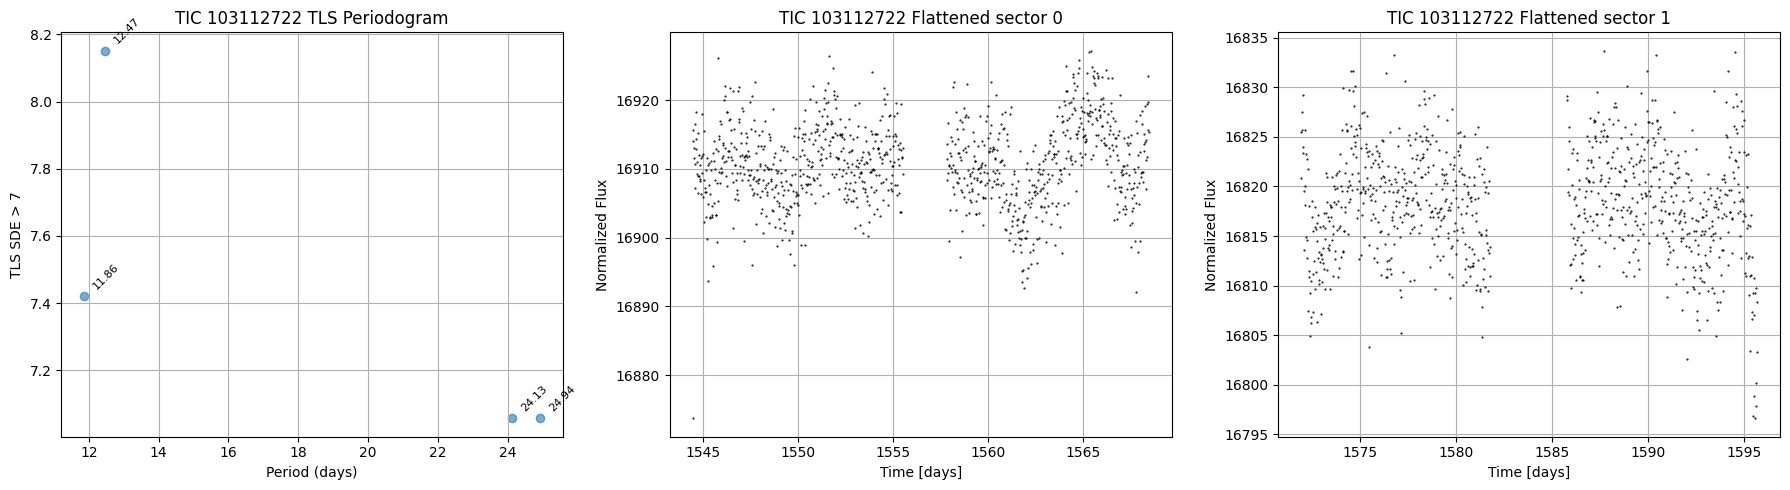

LightCurveCollection of 2 objects:
    0: <TessLightCurve LABEL="TIC 1102352744" SECTOR=15 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 1102352744" SECTOR=23 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


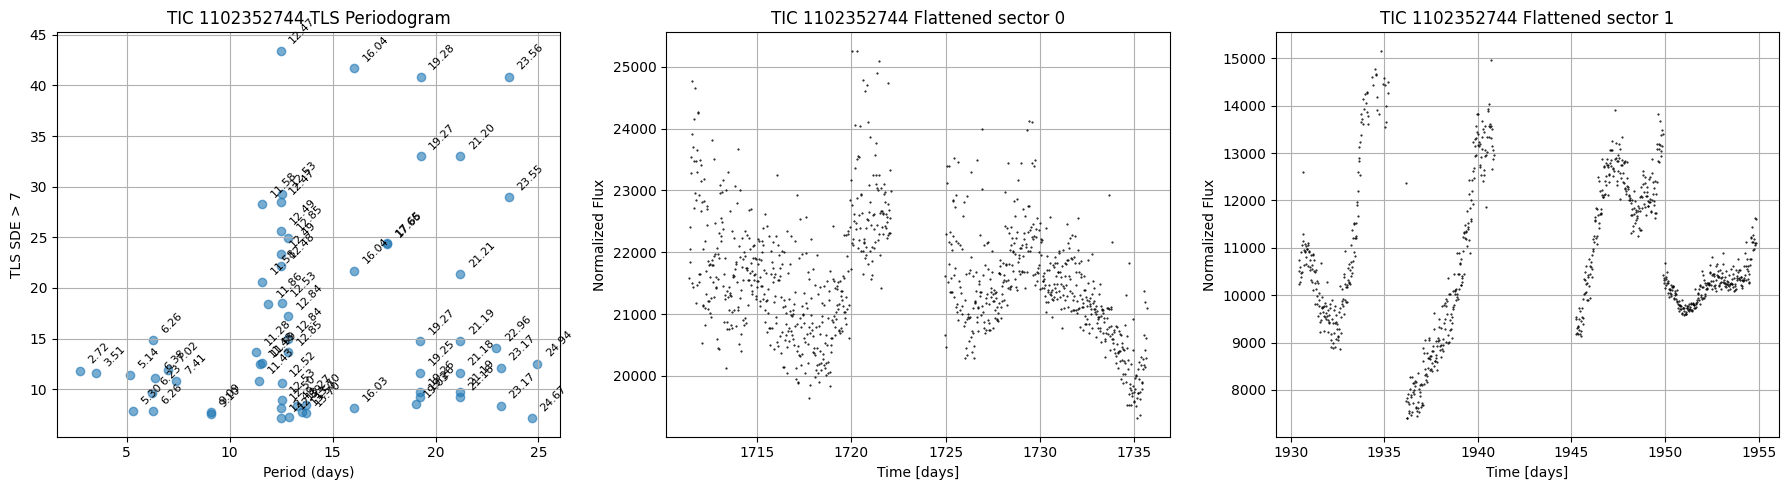

<Figure size 640x480 with 0 Axes>

LightCurveCollection of 2 objects:
    0: <TessLightCurve LABEL="TIC 114859567" SECTOR=2 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 114859567" SECTOR=29 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


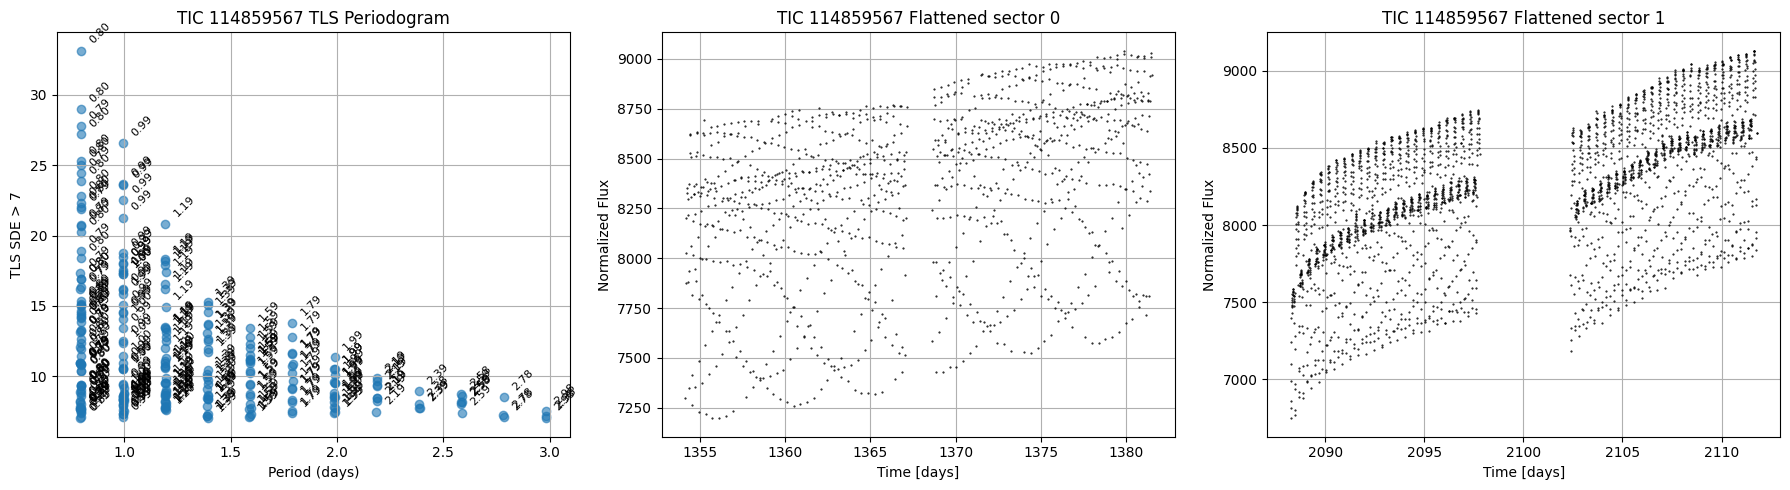

LightCurveCollection of 2 objects:
    0: <TessLightCurve LABEL="TIC 120566166" SECTOR=2 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 120566166" SECTOR=29 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


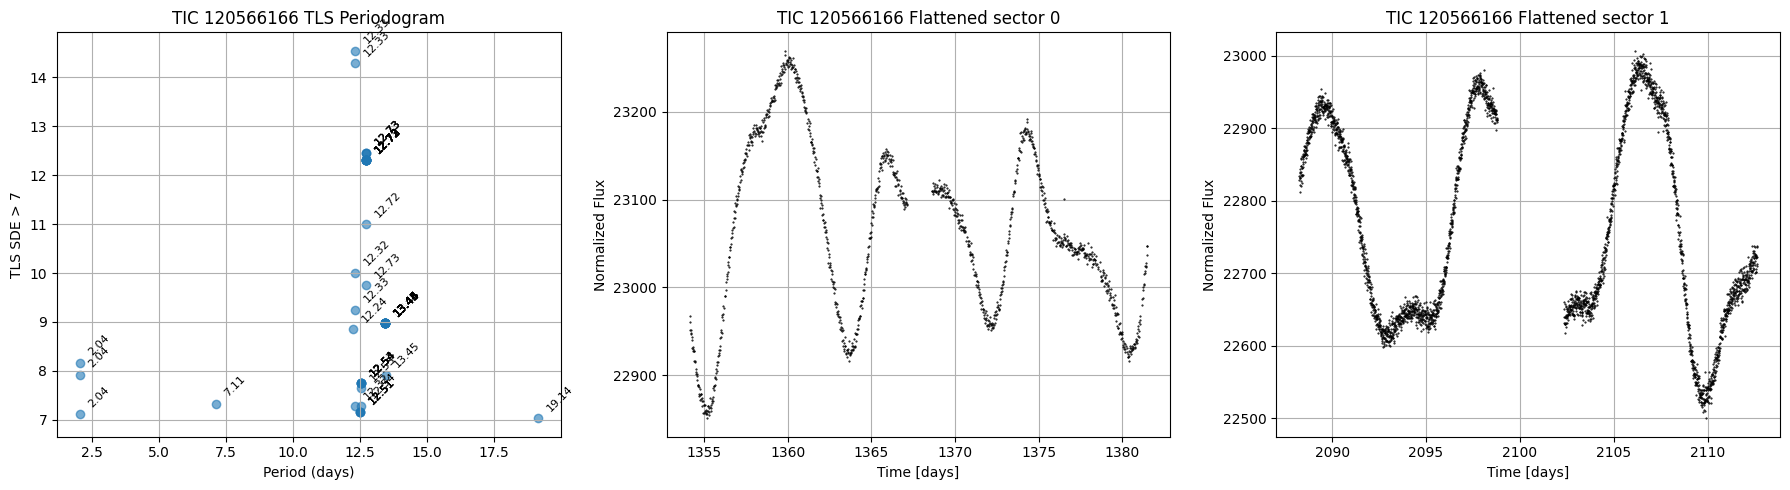

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

LightCurveCollection of 7 objects:
    0: <TessLightCurve LABEL="TIC 387628382" SECTOR=16 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 387628382" SECTOR=17 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 387628382" SECTOR=18 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 387628382" SECTOR=24 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 387628382" SECTOR=25 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 387628382" SECTOR=49 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    6: <TessLightCurve LABEL="TIC 387628382" SECTOR=52 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


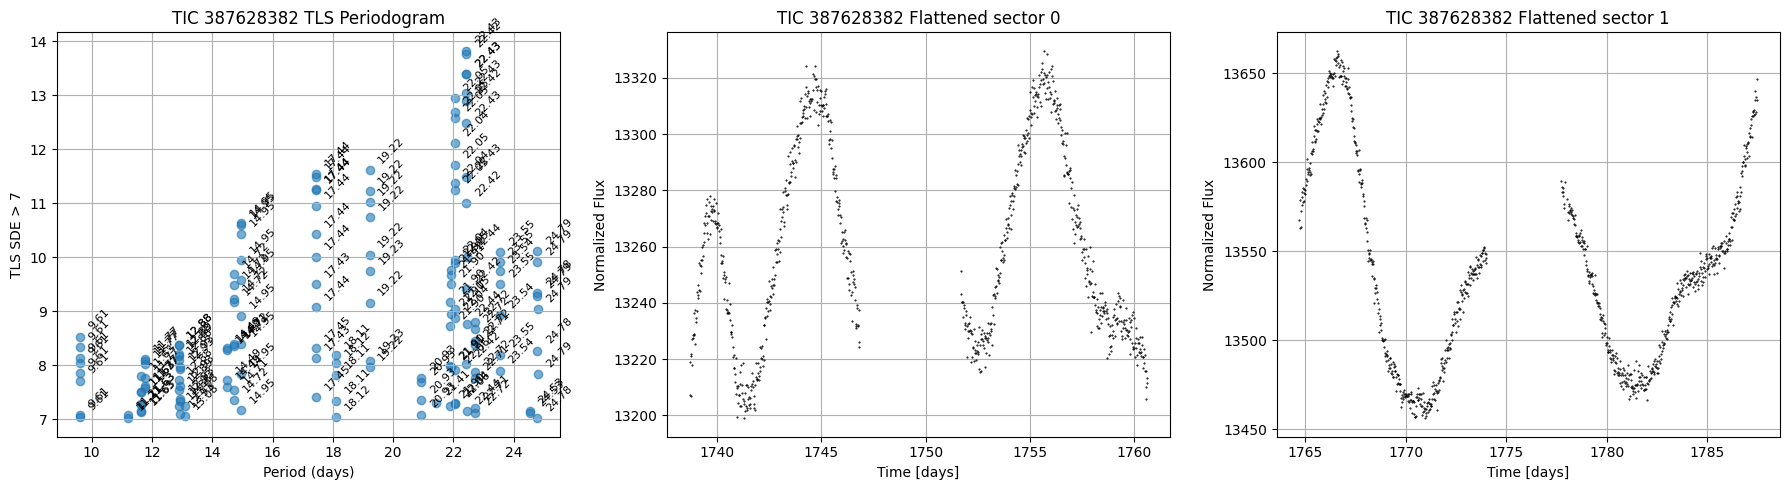

<Figure size 640x480 with 0 Axes>

LightCurveCollection of 4 objects:
    0: <TessLightCurve LABEL="TIC 394026461" SECTOR=25 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 394026461" SECTOR=26 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 394026461" SECTOR=52 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 394026461" SECTOR=53 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


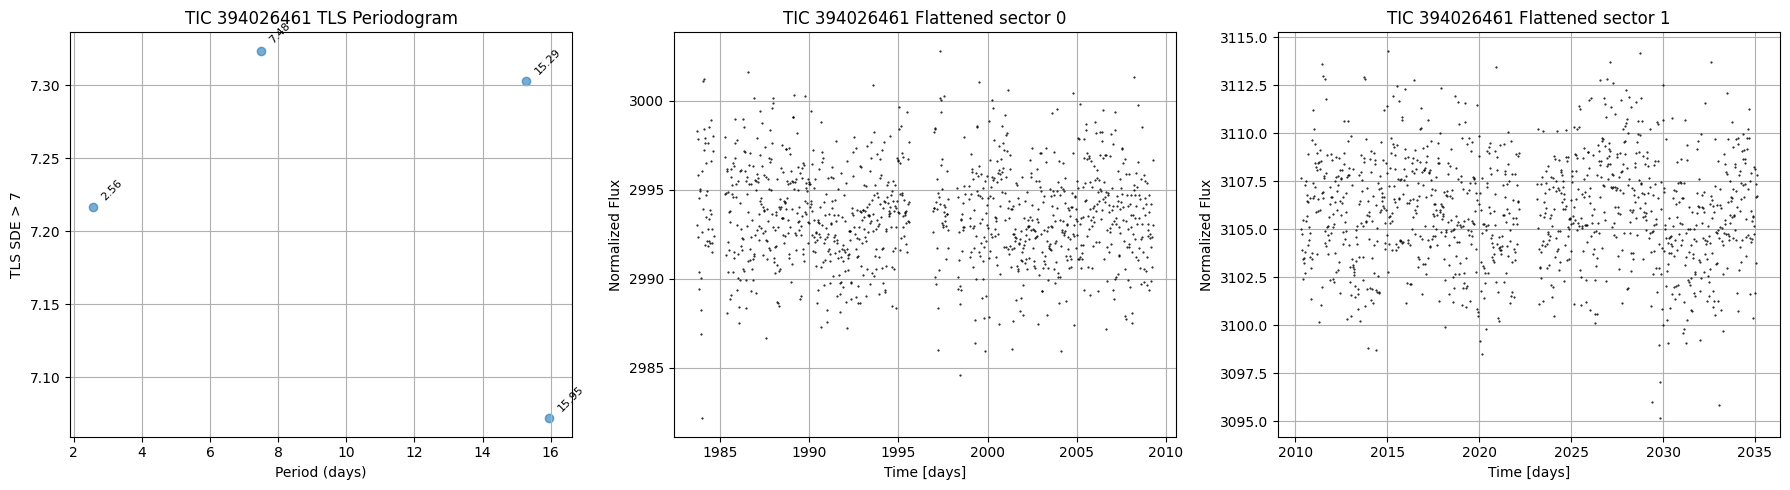

No rows for TIC 17905814


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

No rows for TIC 25978649


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

LightCurveCollection of 1 objects:
    0: <TessLightCurve LABEL="TIC 266500596" SECTOR=19 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


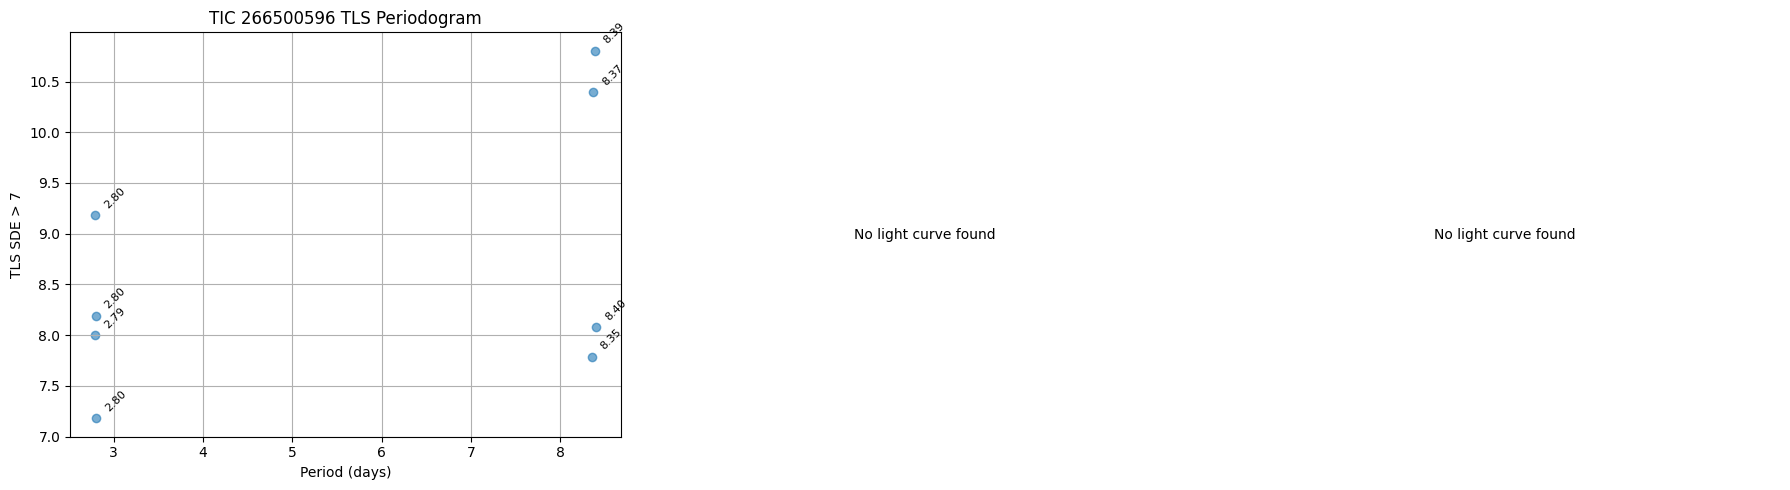

LightCurveCollection of 2 objects:
    0: <TessLightCurve LABEL="TIC 269829146" SECTOR=1 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 269829146" SECTOR=27 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


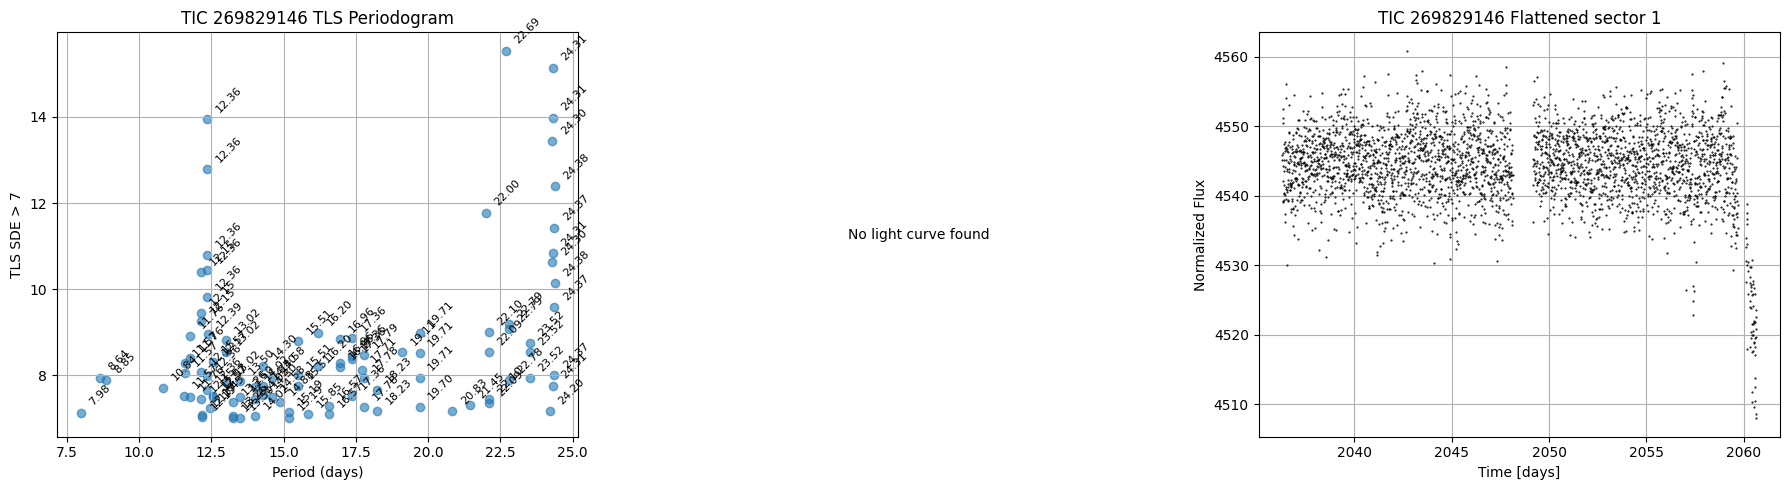

<Figure size 640x480 with 0 Axes>

LightCurveCollection of 2 objects:
    0: <TessLightCurve LABEL="TIC 469870550" SECTOR=1 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 469870550" SECTOR=27 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


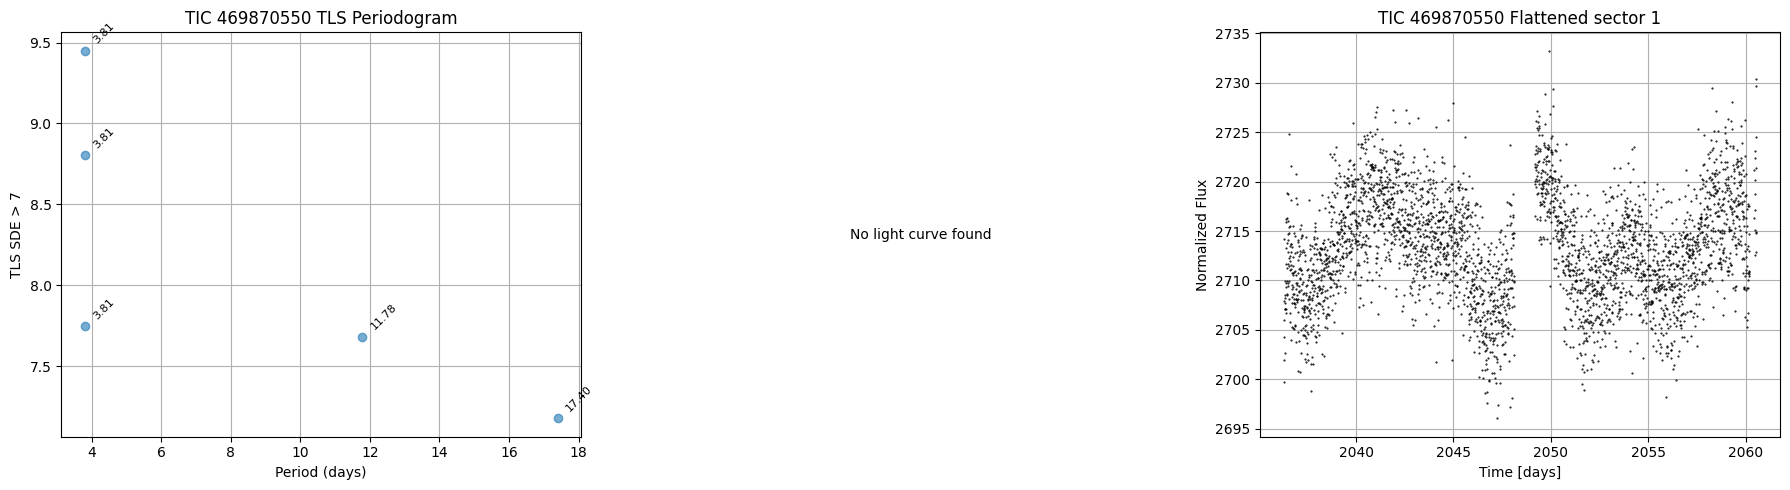

<Figure size 640x480 with 0 Axes>

LightCurveCollection of 4 objects:
    0: <TessLightCurve LABEL="TIC 52211797" SECTOR=6 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 52211797" SECTOR=43 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 52211797" SECTOR=44 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 52211797" SECTOR=45 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


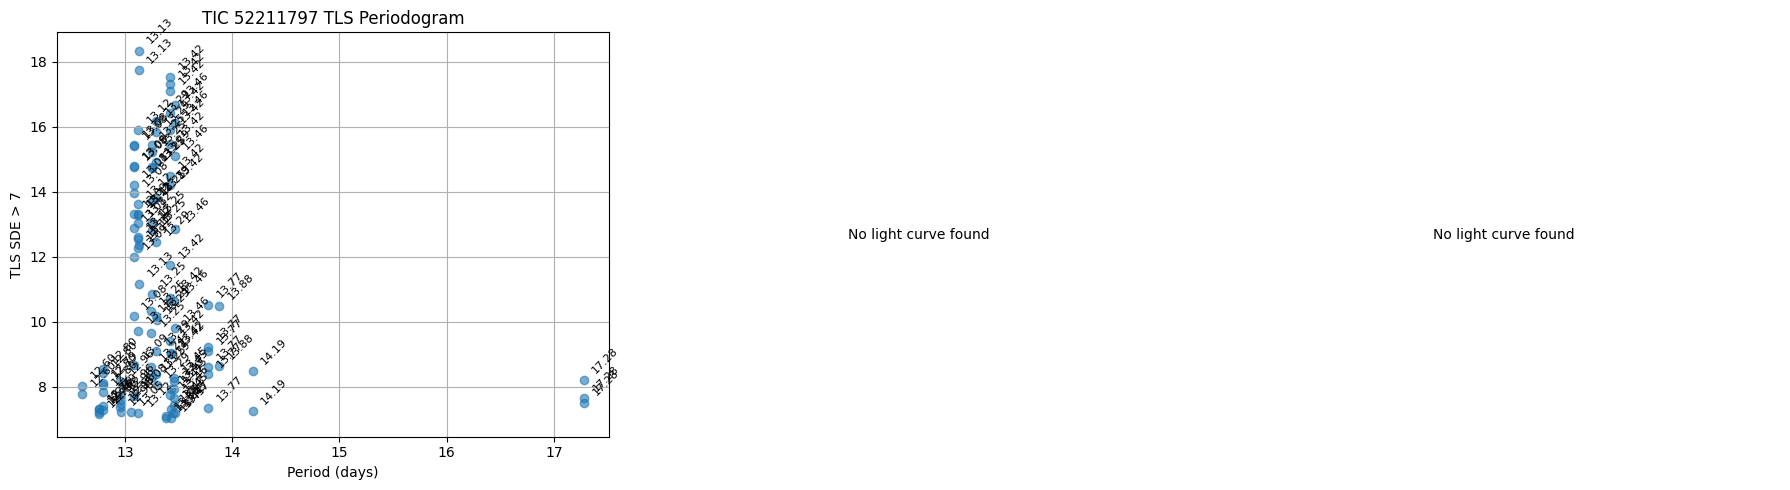

LightCurveCollection of 5 objects:
    0: <TessLightCurve LABEL="TIC 313403564" SECTOR=16 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 313403564" SECTOR=23 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 313403564" SECTOR=24 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 313403564" SECTOR=49 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 313403564" SECTOR=50 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


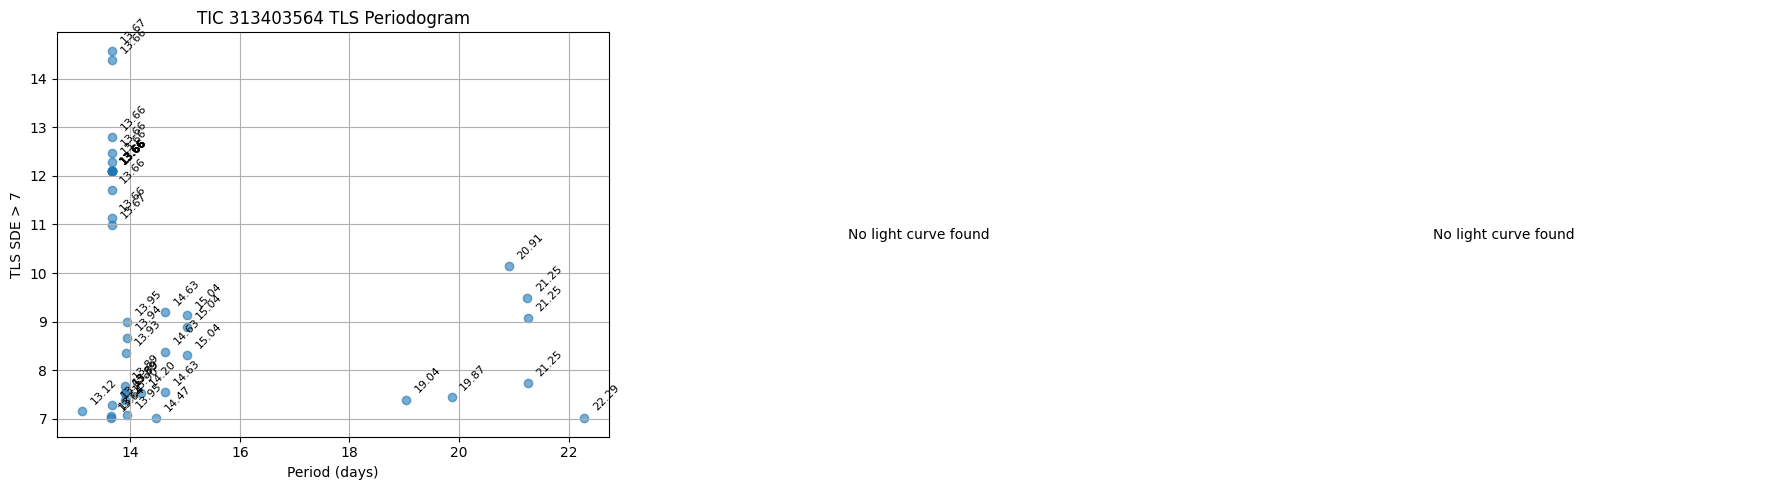

LightCurveCollection of 2 objects:
    0: <TessLightCurve LABEL="TIC 313988572" SECTOR=26 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 313988572" SECTOR=40 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


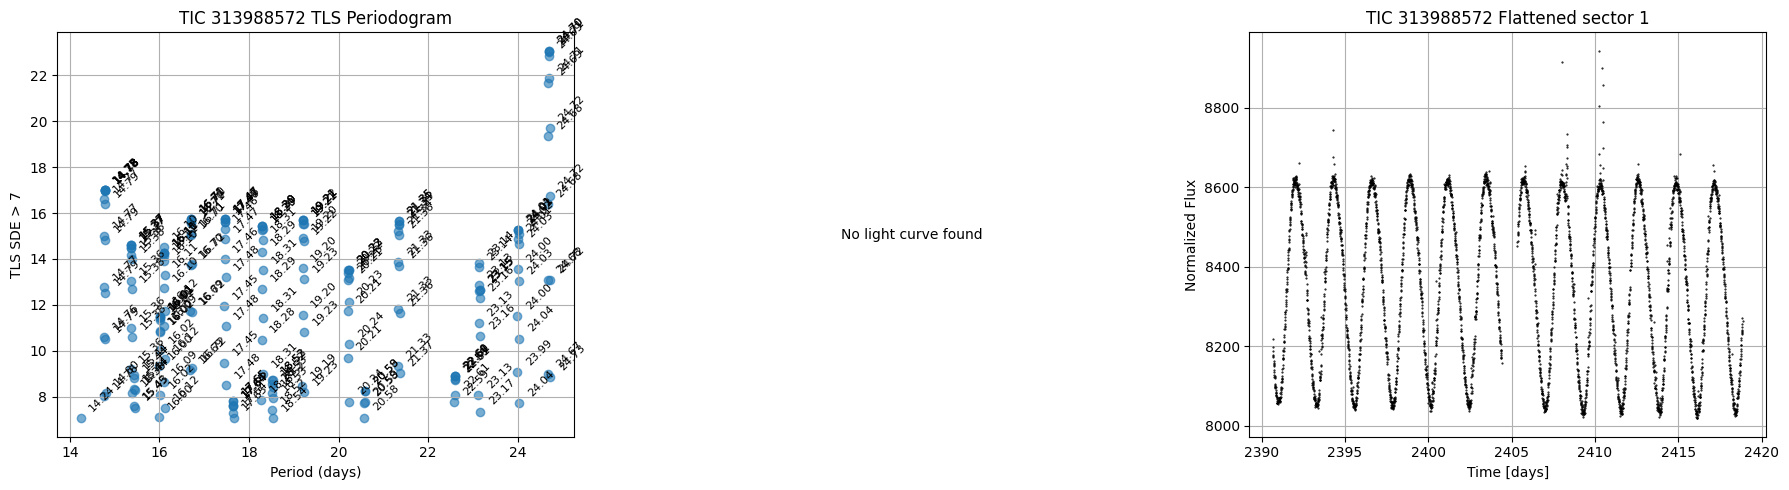

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

LightCurveCollection of 1 objects:
    0: <TessLightCurve LABEL="TIC 316096209" SECTOR=13 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


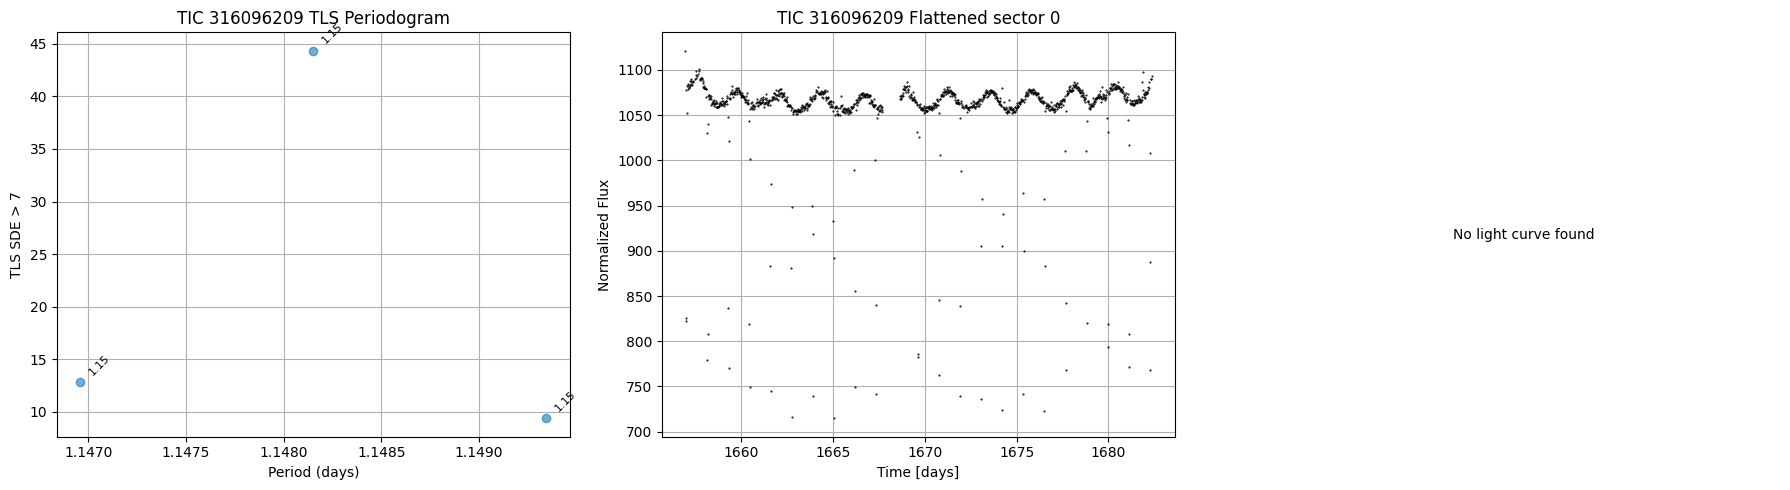

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [1]:
import lightkurve as lk
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


tics = [103112722, 1102352744, 114827044,114859567,120566166,121048612,124533795,385919695,387628382,
        389296668,394026461,17905814,257507933,258060707,25978649,26412365,264722728,26647984,
        266500596,269829146,270301360,469870550,47402214,52211797,313403564,313988572,314713177,
        315104364,316096209,328466136,330123048,178284735]

def mask_flares(df):
    median = df['flux'].median()
    std = df['flux'].std()
    threshold = median + 5 * std
    flare_times = df.loc[df['flux'] > threshold, 'time'].values

    def within_3hr(t):
        return np.any(np.abs(flare_times - t) <= 0.125)

    flare_mask = df['time'].apply(within_3hr)
    return df[~flare_mask].reset_index(drop=True)

# Load CSV
csv_files = glob.glob("rec_only_weird_TIC_recovery.csv")
df_list = [pd.read_csv(f) for f in csv_files]
df = pd.concat(df_list, ignore_index=True)
df = df[['TIC', 'True Radius (Earth Radii)', 'True Period (Days)', 'Detection', '# trials', 'TLS Periods array', 'TLS SDE > 7 array', 'Stellar Radius']]
df = df.drop_duplicates(subset=['TIC', 'True Radius (Earth Radii)', 'True Period (Days)', '# trials'])
for tic in tics:
    tic_str = f'TIC {tic}'
    df_tic = df[df['TIC'] == tic_str]
    
    if df_tic.empty:
        print(f"No rows for TIC {tic}")
        continue

    for idx, row in df_tic.iterrows():
        try:
            periods = np.array([float(p) for p in row['TLS Periods array'].strip('[]').split()])
            sde = np.array([float(s) for s in row['TLS SDE > 7 array'].strip('[]').split()])
        except:
            continue

        if len(periods) != len(sde) or len(periods) == 0:
            continue

        # Create figure: 1 column for TLS, 2 columns for LCs
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # TLS periodogram
        axes[0].scatter(periods, sde, alpha=0.6)
        for p, s in zip(periods, sde):
            axes[0].annotate(f"{p:.2f}", (p, s), textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, rotation=45)
        axes[0].set_xlabel("Period (days)")
        axes[0].set_ylabel("TLS SDE > 7")
        axes[0].set_title(f"TIC {tic} TLS Periodogram")
        axes[0].grid(True)

        # Light curves
        
        lc_collection = lk.search_lightcurve(f'TIC {tic}', mission="TESS", author="TESS-SPOC", cadence="long").download_all(quality_bitmask="hard")
        print(lc_collection)

        for i in [0,1]:
            try:
                lc = lc_collection[i].remove_nans()
                lc_df = pd.DataFrame({'time': lc.time.value, 'flux': lc.flux.value})
                flux_clean = mask_flares(lc_df)
                lc = lk.LightCurve(time=flux_clean['time'], flux=flux_clean['flux'])

                # Flatten
                time = lc.time.value
                cadence_days = np.median(np.diff(time))
                wl = int(np.round(2 / cadence_days))
                if wl % 2 == 0:
                    wl += 1
                lc_flat = lc#.flatten(window_length=wl, polyorder=2)
                flat_df = lc_flat.to_pandas().reset_index()

                # Plot on axes 1 and 2
                axes[i+1].plot(flat_df['time'], flat_df['flux'], 'k.', markersize=1)
                axes[i+1].set_xlabel("Time [days]")
                axes[i+1].set_ylabel("Normalized Flux")
                axes[i+1].set_title(f"TIC {tic} Flattened sector {i}")
                axes[i+1].grid(True)

            except Exception as e:
                axes[i+1].text(0.5, 0.5, "No light curve found", ha='center', va='center')
                axes[i+1].set_axis_off()
                #axes[2].set_axis_off()

    plt.tight_layout()
    plt.show()

